# Modelo 1D transiente del conducto — Calbuco 2015 (v2)

## Mejoras respecto a v1

| Aspecto | v1 | v2 |
|---------|-----|----|
| Integración temporal fuente φ | RK4 explícito (inestable para τ pequeño) | **IMEX**: RK4 advección + exponencial exacta |
| τ_relax recomendado | 50–200 s (frente de frag cerca del vent) | **1 s** (replica exsolución instantánea del estacionario) |
| Post-fragmentación | HEM puro | **Drift-Flux** (v_slip terminal Newton: u_g ≠ u_m) |
| Fricción pared post-frag | viscosa (melt) | **turbulenta** 0.01·ρ·u²/(4r) |
| φ_crit | 0.75 (hardcoded) | **0.8** (desde calbuco2015d) |

## Física

$$\frac{\partial\varphi}{\partial t} + u_m\frac{\partial\varphi}{\partial z} = \frac{\varphi_{eq}(P) - \varphi}{\tau_{relax}}$$

**Esquema IMEX** (splitting de operadores):
1. RK4 para advección pura: $\varphi^* = \varphi^n - \Delta t\,u_m\,\partial_z\varphi$
2. Relajación exponencial exacta (incondicionalmente estable):
$$\varphi^{n+1} = \varphi_{eq}(P) + (\varphi^* - \varphi_{eq})\,e^{-\Delta t/\tau}$$

Con τ → 0: φ → φ_eq(P) instantáneo → **replica el modelo estacionario**.

In [7]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import contextlib, os

from RIconduitex5_5       import RIconduitex5_5_f
from RIconduit1D_transient import RIconduit1D_transient_f
from calbuco2015d import (
    radius1, overP1, h2o1, T1, xi1, phicrit
)

print(f'Parámetros Calbuco 2015:')
print(f'  radio       = {radius1} m')
print(f'  sobrepresión = {overP1/1e6:.1f} MPa')
print(f'  H2O         = {h2o1} wt%')
print(f'  T           = {T1-273.15:.0f} °C')
print(f'  xi          = {xi1}')
print(f'  φ_crit      = {phicrit}')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Parámetros Calbuco 2015:
  radio       = 16 m
  sobrepresión = 5.0 MPa
  H2O         = 4 wt%
  T           = 970 °C
  xi          = 0.25
  φ_crit      = 0.8


## 1. Modelo estacionario → obtener vinicial_conv

In [8]:
with open(os.devnull, 'w') as f:
    with contextlib.redirect_stdout(f):
        result_stat = RIconduitex5_5_f(radius1, overP1, h2o1, T1, xi1)

# [zsol, sol, count, vinicial, rho_m, rbub, visctot, rho_ti, fragcrit, phicrit, limphi1, limphi2, ...]
zsol, sol, count, vinicial_conv, rho_m = result_stat[:5]
phicrit_calc = result_stat[9]   # phicrit calculado dinámicamente por fórmula Ca

print(f'vinicial convergido  : {vinicial_conv:.4f} m/s')
print(f'count                : {count}')
print(f'phi_crit (Ca formula): {phicrit_calc:.4f}  <- el que usa el modelo estacionario')
print(f'phi_crit (calbuco2015d): {phicrit}     <- valor del archivo (no necesariamente el usado)')

vinicial convergido  : 18.3334 m/s
count                : 19
phi_crit (Ca formula): 0.5795  <- el que usa el modelo estacionario
phi_crit (calbuco2015d): 0.8     <- valor del archivo (no necesariamente el usado)


## 2. Modelo transiente (IMEX + Drift-Flux)

In [9]:
out = RIconduit1D_transient_f(
    radius            = radius1,
    Pressure          = overP1,
    wt                = h2o1,
    Temperature       = T1,
    content_crystal   = xi1,
    vinicial_override = vinicial_conv,   # rama explosiva del estacionario
    phicrit_override  = phicrit_calc,    # phicrit calculado dinámicamente (Ca formula)
    tau_relax         = 1.0,             # IMEX: replica estacionario
    N_z               = 200,
    T_max             = 200.0,
    save_every        = 50,
    CFL               = 0.4,
)
print(f'phi_crit usado en transiente: {phicrit_calc:.4f}')

══════════════════════════════════════════════════════════════
  RIconduit1D_transient (HEM + q dinámico) — Parámetros
  Pi      = 1.835e+08 Pa     ρm  = 2463 kg/m³
  q(t=0)  = 11360.8 kg/m²/s   τ_relax = 1 s
  N_z     = 200     Δz  = 35.2 m
  T_max   = 200 s     CFL = 0.4
  φ_crit  = 0.58  (fragmentación)
  CI      : φ = 0 (pre-erupción, sin burbujas)
  P_vent(t=0) = 1.01 bar  (debe ser ~1 bar)
══════════════════════════════════════════════════════════════
  t =      5.3 s   φ_max = 0.9360   um_vent = 349.96 m/s   ug_vent = 356.52 m/s   P_vent = 5.72 bar   q = 76050 kg/m²/s   nfrag = 35   Δt = 0.04 s
  t =      7.3 s   φ_max = 0.9455   um_vent = 349.98 m/s   ug_vent = 356.51 m/s   P_vent = 2.86 bar   q = 91696 kg/m²/s   nfrag = 43   Δt = 0.04 s
  t =      9.2 s   φ_max = 0.9416   um_vent = 349.98 m/s   ug_vent = 358.40 m/s   P_vent = 1.72 bar   q = 98164 kg/m²/s   nfrag = 46   Δt = 0.04 s
  t =     11.2 s   φ_max = 0.9401   um_vent = 349.99 m/s   ug_vent = 359.90 m/s   P_vent = 1.24 b

## 3. Visualización

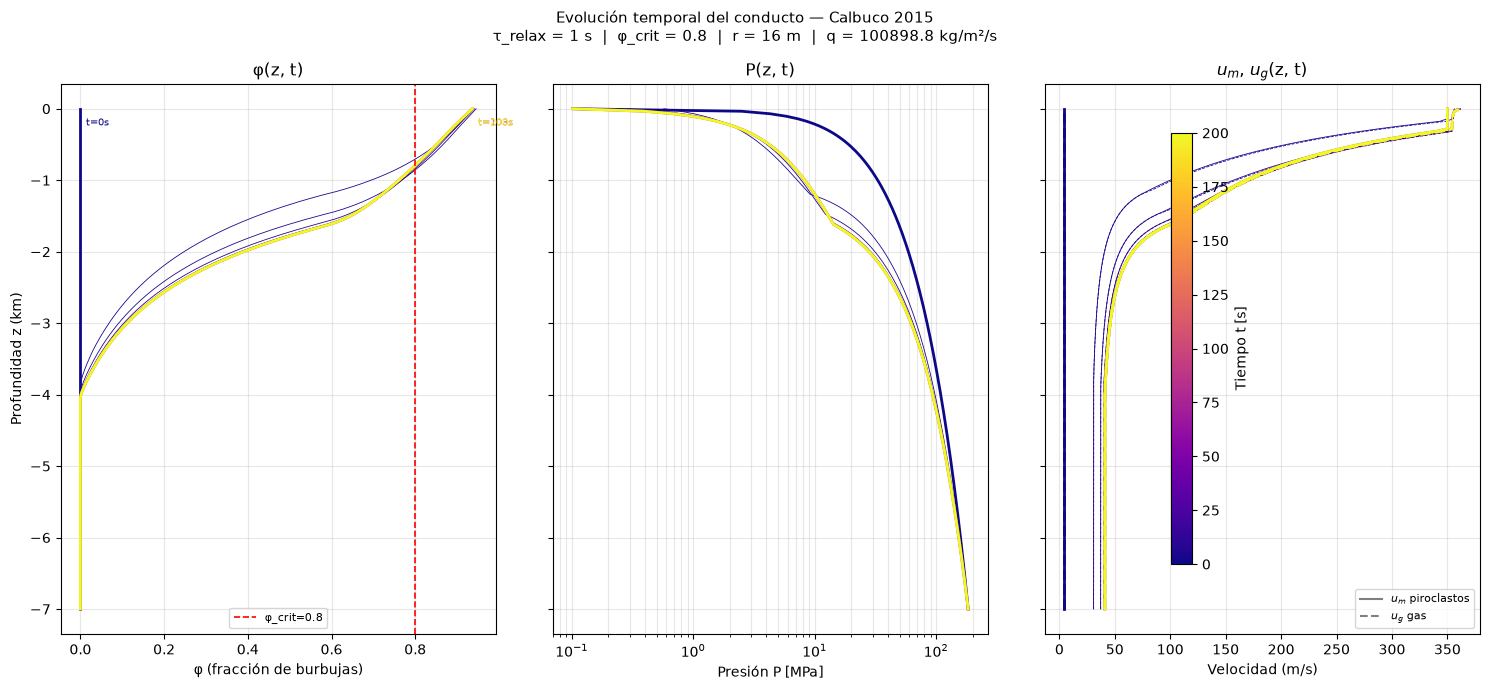

Guardado: transient_calbuco2015_v2.png


In [10]:
t_save   = out['t_save']
z        = out['z']
phi_hist = out['phi_hist']
P_hist   = out['P_hist']
um_hist  = out['um_hist']
ug_hist  = out['ug_hist']
z_km     = z / 1e3

cmap = cm.plasma
norm = plt.Normalize(vmin=t_save.min(), vmax=t_save.max())
sm   = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

idx_0   = 0
idx_mid = len(t_save) // 2
idx_end = len(t_save) - 1
label_idxs = [idx_0, idx_mid, idx_end]

fig, axes = plt.subplots(1, 3, figsize=(15, 7), sharey=True)
fig.suptitle(
    f'Evolución temporal del conducto — Calbuco 2015\n'
    f'τ_relax = 1 s  |  φ_crit = {phicrit}  |  r = {radius1} m  |  '
    f'q = {out["q"]:.1f} kg/m²/s',
    fontsize=11
)

# φ(z,t)
ax = axes[0]
for i, t in enumerate(t_save):
    lw = 2.0 if i in label_idxs else 0.6
    ax.plot(phi_hist[i], z_km, color=cmap(norm(t)), linewidth=lw)
ax.axvline(phicrit, color='red', linestyle='--', lw=1.2, label=f'φ_crit={phicrit}')
for idx in label_idxs:
    ax.annotate(f't={t_save[idx]:.0f}s',
                xy=(phi_hist[idx,-1], z_km[-1]),
                xytext=(4,-12), textcoords='offset points',
                fontsize=7, color=cmap(norm(t_save[idx])))
ax.set_xlabel('φ (fracción de burbujas)')
ax.set_ylabel('Profundidad z (km)')
ax.set_title('φ(z, t)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# P(z,t)
ax = axes[1]
for i, t in enumerate(t_save):
    lw = 2.0 if i in label_idxs else 0.6
    ax.semilogx(P_hist[i]/1e6, z_km, color=cmap(norm(t)), linewidth=lw)
ax.set_xlabel('Presión P [MPa]')
ax.set_title('P(z, t)')
ax.grid(True, alpha=0.3, which='both')

# velocidades
ax = axes[2]
for i, t in enumerate(t_save):
    lw = 2.0 if i in label_idxs else 0.6
    c  = cmap(norm(t))
    ax.plot(um_hist[i], z_km, color=c, linewidth=lw, label='_')
    ax.plot(ug_hist[i], z_km, color=c, linewidth=lw, linestyle='--', label='_')
# leyenda de fases
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0], color='gray', lw=1.5, label='$u_m$ piroclastos'),
    Line2D([0],[0], color='gray', lw=1.5, ls='--', label='$u_g$ gas'),
], fontsize=8)
ax.set_xlabel('Velocidad (m/s)')
ax.set_title('$u_m$, $u_g$(z, t)')
ax.grid(True, alpha=0.3)

fig.colorbar(sm, ax=axes.ravel().tolist(), shrink=0.8, pad=0.02, label='Tiempo t [s]')
plt.tight_layout()
plt.savefig('transient_calbuco2015_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: transient_calbuco2015_v2.png')

## 4. Resumen del estado final

Estado final (t = 200 s):
  phi_max          = 0.9367
  phi_vent (z=0)   = 0.9367
  nfrag            = 23 nodos
  Frente de frag   = -0.77 km
  P_vent           = 1.01 bar  (debe ~1 bar)
  um_vent          = 350.0 m/s
  ug_vent          = 361.5 m/s
  q(t=0)           = 11360.8 kg/m2/s
  q(t_final)       = 100898.8 kg/m2/s  (incremento: x8.88)


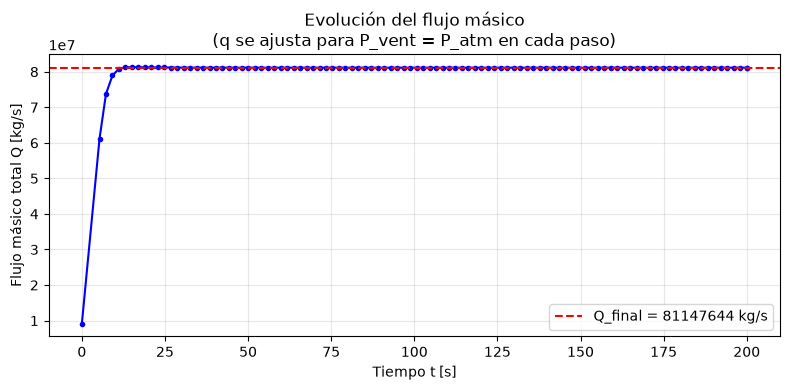

In [11]:
phi_final  = phi_hist[-1]
z_frag_idx = np.where(phi_final >= phicrit)[0]
q_hist     = out['q_hist']

print(f'Estado final (t = {t_save[-1]:.0f} s):')
print(f'  phi_max          = {phi_final.max():.4f}')
print(f'  phi_vent (z=0)   = {phi_final[-1]:.4f}')
print(f'  nfrag            = {len(z_frag_idx)} nodos')
if len(z_frag_idx) > 0:
    print(f'  Frente de frag   = {z[z_frag_idx[0]]/1e3:.2f} km')
print(f'  P_vent           = {P_hist[-1,-1]/1e5:.2f} bar  (debe ~1 bar)')
print(f'  um_vent          = {um_hist[-1,-1]:.1f} m/s')
print(f'  ug_vent          = {ug_hist[-1,-1]:.1f} m/s')
print(f'  q(t=0)           = {q_hist[0]:.1f} kg/m2/s')
print(f'  q(t_final)       = {q_hist[-1]:.1f} kg/m2/s  (incremento: x{q_hist[-1]/q_hist[0]:.2f})')

# --- Flujo másico total en el tiempo ---
A_conduit = np.pi * radius1**2
fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.plot(t_save, np.array(q_hist) * A_conduit, 'b-o', markersize=3)
ax2.set_xlabel('Tiempo t [s]')
ax2.set_ylabel('Flujo másico total Q [kg/s]')
ax2.set_title('Evolución del flujo másico\n(q se ajusta para P_vent = P_atm en cada paso)')
ax2.grid(True, alpha=0.3)
ax2.axhline(q_hist[-1]*A_conduit, color='red', ls='--', label=f'Q_final = {q_hist[-1]*A_conduit:.0f} kg/s')
ax2.legend()
plt.tight_layout()
plt.savefig('q_evolution_calbuco2015.png', dpi=150, bbox_inches='tight')
plt.show()